In [1]:
import tensorflow as tf 
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Create the .kaggle directory (if it doesn't exist)
import os
os.makedirs('C:/Users/A/.kaggle', exist_ok=True)

# Copy from Desktop to Kaggle folder
!copy "C:\Users\A\Desktop\kaggle.json" "C:\Users\A\.kaggle\"

        0 file(s) copied.


Access is denied.


In [3]:
# Make the file read-only for your user (Windows equivalent of chmod 600)
!attrib +R "C:\Users\A\.kaggle\kaggle.json"

In [4]:
!kaggle datasets list  # Should show datasets without errors

usage: kaggle [-h] [-v] [-W]
              {competitions,c,datasets,d,kernels,k,models,m,files,f,config}
              ...
kaggle: error: unrecognized arguments: # Should show datasets without errors


In [5]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown


In [6]:
import zipfile
with zipfile.ZipFile('face-mask-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('face-mask-data')
    
# Verify
!ls face-mask-data

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [7]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [8]:
import zipfile

# Fix the typo in ZipFile (capital 'F')
with zipfile.ZipFile('face-mask-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('face-mask-data')

In [9]:
# For Windows Jupyter Notebook/Lab:
import os
print("Extracted files:", os.listdir('face-mask-data'))

Extracted files: ['data']


In [10]:
import os

# Check what's REALLY inside the data folder
data_path = 'face-mask-data/data'
print("Actual contents:", os.listdir(data_path))

# The dataset might have direct 'with_mask' and 'without_mask' folders
if {'with_mask', 'without_mask'}.issubset(os.listdir(data_path)):
    print("\nDataset structure found:")
    print(f"- with_mask samples: {len(os.listdir(f'{data_path}/with_mask'))}")
    print(f"- without_mask samples: {len(os.listdir(f'{data_path}/without_mask'))}")
else:
    print("\nERROR: Unexpected structure. Full path contents:")
    for root, dirs, files in os.walk('face-mask-data'):
        print(f"{root} contains: {dirs + files}")

Actual contents: ['without_mask', 'with_mask']

Dataset structure found:
- with_mask samples: 3725
- without_mask samples: 3828


In [11]:
import os
import zipfile
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Extract dataset
with zipfile.ZipFile('face-mask-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('face-mask-data')

# 2. Verify ACTUAL structure
data_path = 'face-mask-data/data'
print("Found folders:", os.listdir(data_path))  # Should show ['with_mask', 'without_mask']

# 3. Create generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_path,  # Point directly to 'data'
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

print("\nClasses:", train_generator.class_indices)

Found folders: ['without_mask', 'with_mask']
Found 6043 images belonging to 2 classes.

Classes: {'with_mask': 0, 'without_mask': 1}


In [12]:
# Import required libraries
import os
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt

# 1. GET IMAGE PATHS AND LABELS
# -----------------------------
# Create lists to store file paths and corresponding labels (0=with_mask, 1=without_mask)
image_paths = []
labels = []

# Loop through each class folder
for class_name in ['with_mask', 'without_mask']:
    class_folder = os.path.join('face-mask-data/data', class_name)
    
    # Get all image files in the folder
    for img_file in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_file)
        image_paths.append(img_path)
        labels.append(0 if class_name == 'with_mask' else 1)

# 2. SPLIT DATA (80% train, 20% test)
# -----------------------------------
# Using sklearn's train_test_split with stratification to maintain class balance
X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    image_paths,          # List of image paths
    labels,               # Corresponding labels
    test_size=0.2,        # 20% for testing
    stratify=labels,      # Keep same class ratios
    random_state=42       # For reproducibility
)


In [13]:
#preprocces immages 
def load_images(path_list, img_size=(64,64)):
    images = []
    for path in path_list:
        img = load_img(path, target_size=img_size)  
        img_array = img_to_array(img) / 255.0       # Convert to array and normalize [0-1]
        images.append(img_array)
    return np.array(images)

# Convert paths to actual image arrays
X_train = load_images(X_train_paths)
X_test = load_images(X_test_paths)

d:\A\anaconda\envs\tf-cpu\lib\site-packages\PIL\Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [14]:
# Convert labels to numpy arrays
y_train = np.array(y_train)
y_test = np.array(y_test)

In [15]:
#one hot encoded 
#y_train = to_categorical(y_train,num_classes=2)
#y_test = to_categorical(y_test,num_classes=2)

In [16]:
print(f"Training data: {X_train.shape}")  
print(f"Test data: {X_test.shape}")       

Training data: (6042, 64, 64, 3)
Test data: (1511, 64, 64, 3)


In [17]:
print(y_test[:5])

[1 0 1 0 1]


In [18]:
classes = ["with mask","without_mask"] # 0 for with mask, 1 for without mask 

In [19]:

def plot_sample(x,y,index):
    plt.figure(figsize=(15,2))
    plt.imshow(x[index])
    plt.xlabel(classes[np.argmax(y[index])]) 


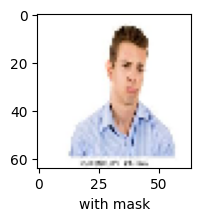

In [20]:
plot_sample(X_train,y_train,5) # plotting the 4th image in trainng set 

In [21]:

model = models.Sequential([
    # Conv layer 1 (32 filters)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64,64,3)),
    layers.MaxPooling2D((2, 2)),

    # Conv layer 2 (64 filters)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Conv layer 3 (128 filters)
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Conv layer 4 (256 filters)
    layers.Conv2D(256, (3, 3), activation='relu'),
    
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(2, activation='sigmoid')  
])



d:\A\anaconda\envs\tf-cpu\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,437,762 (5.48 MB)

 Trainable params: 1,437,762 (5.48 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2  # 20% validation
)

Epoch 1/5


ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(None,), output.shape=(None, 2)

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9616 - loss: 0.1248
Test Accuracy: 0.9636


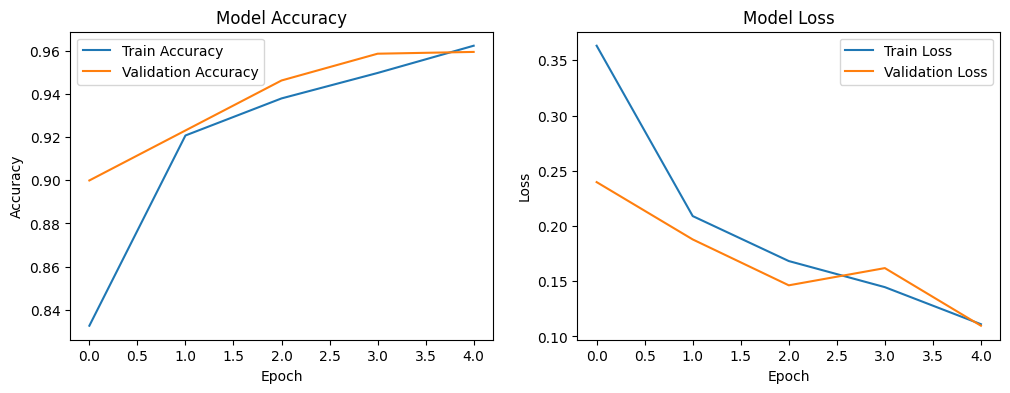

In [ ]:

# Accuracy plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()

In [ ]:
def show_predictions(model, test_images, test_labels, num_samples=5):
    predictions = model.predict(test_images[:num_samples])
    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i+1)
        plt.imshow(test_images[i])
        
        true_class = np.argmax(test_labels[i])
        pred_class = np.argmax(predictions[i])
        
        plt.title(f"True: {classes[true_class]}\nPred: {classes[pred_class]}")
    plt.show()

show_predictions(model, X_test, y_test, num_samples=5) # predict the first 5 images from the0

NameError: name 'model' is not defined

In [ ]:
from sklearn.metrics import classification_report

y_pred = (model.predict(X_test) > 0.5).astype("int32")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['with_mask', 'without_mask']))

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Classification Report:
              precision    recall  f1-score   support

   with_mask       0.96      0.89      0.92       745
without_mask       0.91      0.96      0.93       766

   micro avg       0.93      0.93      0.93      1511
   macro avg       0.93      0.93      0.93      1511
weighted avg       0.93      0.93      0.93      1511
 samples avg       0.93      0.93      0.93      1511



d:\A\anaconda\envs\tf-cpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,313,288 (16.45 MB)

 Trainable params: 1,437,762 (5.48 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,875,526 (10.97 MB)